Boundary points: 400
Interior points: 1444
Overlap size: 0


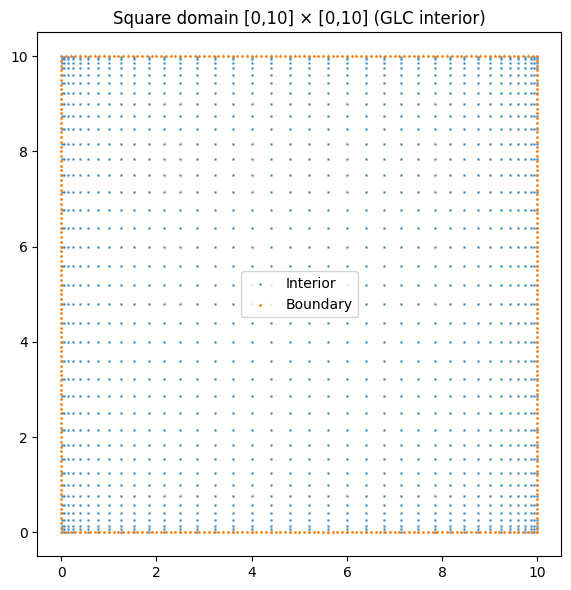

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# PARAMETERS
# ==========================================================
a, b = 0.0, 10.0
Nx_b = 101   # boundary resolution per edge
Nx_i = 40    # number of GLC nodes per direction

# ==========================================================
# Helper: Gauss–Lobatto–Chebyshev nodes in [a,b]
# ==========================================================
def chebyshev_lobatto_nodes(N, a, b):
    """
    Returns N Gauss–Lobatto–Chebyshev nodes mapped to [a,b]
    """
    k = np.arange(N)
    x = -np.cos(np.pi * k / (N - 1))   # in [-1,1]

    # map to [a,b]
    return 0.5 * (b - a) * (x + 1) + a

# ==========================================================
# 1. BOUNDARY POINTS
# ==========================================================
t = np.linspace(a, b, Nx_b)

bottom = np.column_stack([t, np.full_like(t, a)])
top    = np.column_stack([t, np.full_like(t, b)])
left   = np.column_stack([np.full_like(t[1:-1], a), t[1:-1]])
right  = np.column_stack([np.full_like(t[1:-1], b), t[1:-1]])

boundary_pts = np.vstack([bottom, right, top[::-1], left[::-1]])
boundary_pts = np.unique(boundary_pts, axis=0)

# ==========================================================
# 2. INTERIOR POINTS — GLC tensor grid
# ==========================================================
xi = chebyshev_lobatto_nodes(Nx_i, a, b)
yi = chebyshev_lobatto_nodes(Nx_i, a, b)

X, Y = np.meshgrid(xi, yi)

grid = np.column_stack([X.ravel(), Y.ravel()])

# strict interior mask
mask = (
    (grid[:,0] > a) & (grid[:,0] < b) &
    (grid[:,1] > a) & (grid[:,1] < b)
)

interior_pts = grid[mask]
interior_pts = np.unique(interior_pts, axis=0)

# ==========================================================
# 3. SAFETY CHECKS
# ==========================================================
intersection = set(map(tuple, interior_pts)) & set(map(tuple, boundary_pts))

print("Boundary points:", boundary_pts.shape[0])
print("Interior points:", interior_pts.shape[0])
print("Overlap size:", len(intersection))

# ==========================================================
# 4. PLOT
# ==========================================================
plt.figure(figsize=(6,6))

plt.scatter(
    interior_pts[:,0],
    interior_pts[:,1],
    s=1,
    label="Interior",
    alpha=0.6
)

plt.scatter(
    boundary_pts[:,0],
    boundary_pts[:,1],
    s=1,
    label="Boundary",
    marker='o'
)

plt.gca().set_aspect('equal')

plt.title("Square domain [0,10] × [0,10] (GLC interior)")
plt.legend()

plt.tight_layout()
plt.show()

# ==========================================================
# 5. SAVE ARRAYS IN data/ FOLDER
# ==========================================================
os.makedirs(
    "data",
    exist_ok=True
)

np.save(
    "data/square_interior_points.npy",
    interior_pts
)

np.save(
    "data/square_boundary_points.npy",
    boundary_pts
)
